# Before you start:
- Read the README.md file
- Comment as much as you can and use the resources (README.md file)
- Happy learning!

In [4]:
import pandas as pd              
import numpy as np
from scipy.stats import trim_mean  
from statsmodels import robust     
import wquantiles              
import random
import seaborn as sns
import matplotlib.pylab as plt

# Challenge 1 - Exploring the Data

In this challenge, we will examine all salaries of employees of the City of Chicago. We will start by loading the dataset and examining its contents. Please, load the data using Ironhack's database (db: employees, table: employees_advanced).

In [5]:
employees = pd.read_csv("../data/Current_Employee_Names__Salaries__and_Position_Titles.csv")


Examine the `salaries` dataset using the `head` function below.

In [6]:
employees.head()


,Name,Job Titles,Department,Full or Part-Time,Salary or Hourly,Typical Hours,Annual Salary,Hourly Rate
0,"AARON, JEFFERY M",SERGEANT,POLICE,F,Salary,NaN,101442.0,NaN
1,"AARON, KARINA",POLICE OFFICER (ASSIGNED AS DETECTIVE),POLICE,F,Salary,NaN,94122.0,NaN
2,"AARON, KIMBERLEI R",CHIEF CONTRACT EXPEDITER,GENERAL SERVICES,F,Salary,NaN,101592.0,NaN
3,"ABAD JR, VICENTE M",CIVIL ENGINEER IV,WATER MGMNT,F,Salary,NaN,110064.0,NaN
4,"ABASCAL, REECE E",TRAFFIC CONTROL AIDE-HOURLY,OEMC,P,Hourly,20.0,NaN,19.86


We see from looking at the `head` function that there is quite a bit of missing data. Let's examine how much missing data is in each column. Produce this output in the cell below

In [7]:
# Calcular el número de valores nulos en cada columna
valores_nulos = employees.isnull().sum()

# Mostrar los valores nulos
print(valores_nulos)



Name                     0
Job Titles               0
Department               0
Full or Part-Time        0
Salary or Hourly         0
Typical Hours        25161
Annual Salary         8022
Hourly Rate          25161
dtype: int64


Let's also look at the count of hourly vs. salaried employees. Write the code in the cell below

In [8]:
# Contar el número de empleados por tipo (Hourly vs. Salaried)
conteo_tipo_empleado = employees['Salary or Hourly'].value_counts()

# Mostrar el conteo
print(conteo_tipo_empleado)




Salary or Hourly
Salary    25161
Hourly     8022
Name: count, dtype: int64


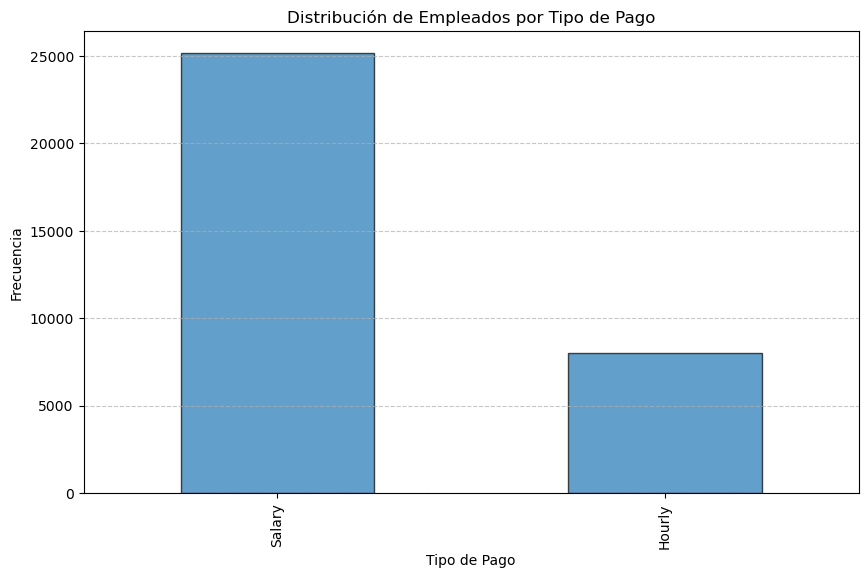

In [9]:
# Graficar el histograma de la columna 'Salary or Hourly'
plt.figure(figsize=(10, 6))
employees['Salary or Hourly'].value_counts().plot(kind='bar', edgecolor='black', alpha=0.7)
plt.title('Distribución de Empleados por Tipo de Pago')
plt.xlabel('Tipo de Pago')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


What this information indicates is that the table contains information about two types of employees - salaried and hourly. Some columns apply only to one type of employee while other columns only apply to another kind. This is why there are so many missing values. Therefore, we will not do anything to handle the missing values.

There are different departments in the city. List all departments and the count of employees in each department.

In [10]:
# Contar el número de empleados en cada departamento
conteo_departamentos = employees['Department'].value_counts()

# Mostrar el conteo
print(conteo_departamentos)




Department
POLICE                   13414
FIRE                      4641
STREETS & SAN             2198
OEMC                      2102
WATER MGMNT               1879
AVIATION                  1629
TRANSPORTN                1140
PUBLIC LIBRARY            1015
GENERAL SERVICES           980
FAMILY & SUPPORT           615
FINANCE                    560
HEALTH                     488
CITY COUNCIL               411
LAW                        407
BUILDINGS                  269
COMMUNITY DEVELOPMENT      207
BUSINESS AFFAIRS           171
COPA                       116
BOARD OF ELECTION          107
DoIT                        99
PROCUREMENT                 92
INSPECTOR GEN               87
MAYOR'S OFFICE              85
CITY CLERK                  84
ANIMAL CONTRL               81
HUMAN RESOURCES             79
CULTURAL AFFAIRS            65
BUDGET & MGMT               46
ADMIN HEARNG                39
DISABILITIES                28
TREASURER                   22
HUMAN RELATIONS             

# Challenge 2 - Hypothesis Tests

In this section of the lab, we will test whether the hourly wage of all hourly workers is significantly different from $30/hr. Import the correct one sample test function from scipy and perform the hypothesis test for a 95% two sided confidence interval.

In [14]:
#hipoteis nula = H0
#hipotesis alternativa = H1
import pandas as pd
from scipy.stats import ttest_1samp #IMPORTAMOS EL METODO 


# Filtrar solo los empleados por hora
hourly_wages = employees['Hourly Rate'].dropna()

# Realizar el test de hipótesis
t_stat, p_value = ttest_1samp(hourly_wages, 30)

# Mostrar los resultados
print("T-statistic:", t_stat)
print("P-value:", p_value)

# Interpretar el resultado
alpha = 0.025
if p_value < alpha:
    print("Rechazamos la hipótesis nula: El salario por hora es significativamente diferente de $30/hr.")
else:
    print("No podemos rechazar la hipótesis nula: No hay evidencia suficiente para afirmar que el salario por hora es significativamente diferente de $30/hr.")


T-statistic: 20.6198057854942
P-value: 4.3230240486229894e-92
Rechazamos la hipótesis nula: El salario por hora es significativamente diferente de $30/hr.


We are also curious about salaries in the police force. The chief of police in Chicago claimed in a press briefing that salaries this year are higher than last year's mean of $86000/year a year for all salaried employees. Test this one sided hypothesis using a 95% confidence interval.

Hint: A one tailed test has a p-value that is half of the two tailed p-value. If our hypothesis is greater than, then to reject, the test statistic must also be positive.

In [28]:
# Filtrar solo los empleados asalariados del departamento de policía
police_salaries = employees[(employees['Department'] == 'POLICE') & (employees['Salary or Hourly'] == 'Salary')]['Annual Salary'].dropna()

# Realizar el test de hipótesis
t_stat, p_value_two_tailed = ttest_1samp(police_salaries, 86000)

# Ajustar el valor p para una prueba de una cola
p_value_one_tailed = p_value_two_tailed / 2

# Mostrar los resultados
print("T-statistic:", t_stat)
print("P-value (one-tailed):", p_value_one_tailed)

# Interpretar el resultado
alpha = 0.05
if p_value_one_tailed < alpha and t_stat > 0:
    print("Rechazamos la hipótesis nula: Los salarios este año son significativamente mayores que $86,000/año.")
else:
    print("No podemos rechazar la hipótesis nula: No hay evidencia suficiente para afirmar que los salarios este año son significativamente mayores que $86,000/año.")


T-statistic: 3.081997005712994
P-value (one-tailed): 0.0010301701775482569
Rechazamos la hipótesis nula: Los salarios este año son significativamente mayores que $86,000/año.


Using the `crosstab` function, find the department that has the most hourly workers. 

In [25]:
# Crear una tabla cruzada para contar el número de trabajadores por hora en cada departamento
tabla_cruzada = pd.crosstab(employees['Department'], employees['Salary or Hourly'])

# Filtrar solo los trabajadores por hora y encontrar el departamento con más trabajadores por hora
departamento_mas_horarios = tabla_cruzada['Hourly'].idxmax()
conteo_mas_horarios = tabla_cruzada['Hourly'].max()

# Mostrar el resultado
print("El departamento con más trabajadores por hora es:", departamento_mas_horarios, "con", conteo_mas_horarios, "trabajadores por hora.")


El departamento con más trabajadores por hora es: STREETS & SAN con 1862 trabajadores por hora.


The workers from the department with the most hourly workers have complained that their hourly wage is less than $35/hour. Using a one sample t-test, test this one-sided hypothesis at the 95% confidence level.

In [26]:
# Filtrar solo los empleados por hora del departamento con más trabajadores por hora
hourly_wages =employees[(employees['Department'] == departamento_mas_horarios) & (employees['Salary or Hourly'] == 'Hourly')]['Hourly Rate'].dropna()

# Realizar el test de hipótesis
t_stat, p_value_two_tailed = ttest_1samp(hourly_wages, 35)

# Ajustar el valor p para una prueba de una cola
p_value_one_tailed = p_value_two_tailed / 2

# Mostrar los resultados
print(f"T-statistic: {t_stat}")
print(f"P-value (one-tailed): {p_value_one_tailed}")

# Interpretar el resultado
alpha = 0.05
if p_value_one_tailed < alpha and t_stat < 0:
    print("Rechazamos la hipótesis nula: El salario por hora es significativamente menor que $35/hr.")
else:
    print("No podemos rechazar la hipótesis nula: No hay evidencia suficiente para afirmar que el salario por hora es significativamente menor que $35/hr.")
 



T-statistic: -9.567447887848152
P-value (one-tailed): 1.6689265282353859e-21
Rechazamos la hipótesis nula: El salario por hora es significativamente menor que $35/hr.


# Challenge 3: To practice - Constructing Confidence Intervals

While testing our hypothesis is a great way to gather empirical evidence for accepting or rejecting the hypothesis, another way to gather evidence is by creating a confidence interval. A confidence interval gives us information about the true mean of the population. So for a 95% confidence interval, we are 95% sure that the mean of the population is within the confidence interval. 
).

To read more about confidence intervals, click [here](https://en.wikipedia.org/wiki/Confidence_interval).


In the cell below, we will construct a 95% confidence interval for the mean hourly wage of all hourly workers. 

The confidence interval is computed in SciPy using the `t.interval` function. You can read more about this function [here](https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.stats.t.html).

To compute the confidence interval of the hourly wage, use the 0.95 for the confidence level, number of rows - 1 for degrees of freedom, the mean of the sample for the location parameter and the standard error for the scale. The standard error can be computed using [this](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.sem.html) function in SciPy.

In [30]:
from scipy.stats import t
# Filtrar solo los empleados por hora
hourly_wages =employees[employees['Salary or Hourly'] == 'Hourly']['Hourly Rate'].dropna()

# Calcular la media y el error estándar
mean_hourly_wage = np.mean(hourly_wages)
std_error = np.std(hourly_wages, ddof=1) / np.sqrt(len(hourly_wages))

# Calcular el intervalo de confianza del 95%
confidence_level = 0.95
degrees_freedom = len(hourly_wages) - 1
confidence_interval = t.interval(confidence_level, degrees_freedom, loc=mean_hourly_wage, scale=std_error)

# Mostrar el intervalo de confianza
print(f"El intervalo de confianza del 95% para el salario por hora es: {confidence_interval}")



El intervalo de confianza del 95% para el salario por hora es: (32.52345834488425, 33.05365708767623)


Now construct the 95% confidence interval for all salaried employeed in the police in the cell below.

In [29]:
# Filtrar solo los empleados asalariados del departamento de policía
police_salaries =employees[(employees['Department'] == 'POLICE') & (employees['Salary or Hourly'] == 'Salary')]['Annual Salary'].dropna()

# Calcular la media y el error estándar
mean_salary = np.mean(police_salaries)
std_error = np.std(police_salaries, ddof=1) / np.sqrt(len(police_salaries))

# Calcular el intervalo de confianza del 95%
confidence_level = 0.95
degrees_freedom = len(police_salaries) - 1
confidence_interval = t.interval(confidence_level, degrees_freedom, loc=mean_salary, scale=std_error)

# Mostrar el intervalo de confianza
print(f"El intervalo de confianza del 95% para el salario anual es: {confidence_interval}")



El intervalo de confianza del 95% para el salario anual es: (86177.05631531785, 86795.77269094893)


# Bonus Challenge - Hypothesis Tests of Proportions

Another type of one sample test is a hypothesis test of proportions. In this test, we examine whether the proportion of a group in our sample is significantly different than a fraction. 

You can read more about one sample proportion tests [here](http://sphweb.bumc.bu.edu/otlt/MPH-Modules/BS/SAS/SAS6-CategoricalData/SAS6-CategoricalData2.html).

In the cell below, use the `proportions_ztest` function from `statsmodels` to perform a hypothesis test that will determine whether the number of hourly workers in the City of Chicago is significantly different from 25% at the 95% confidence level.

In [31]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

# Contar el número de empleados por hora y el número total de empleados
num_hourly_workers = employees[employees['Salary or Hourly'] == 'Hourly'].shape[0]
num_total_workers = employees.shape[0]

# Definir la proporción esperada (25%)
proporcion_esperada = 0.25

# Realizar el test de hipótesis
count = num_hourly_workers
nobs = num_total_workers
stat, p_value = proportions_ztest(count, nobs, proporcion_esperada)

# Mostrar los resultados
print(f"Z-statistic: {stat}")
print(f"P-value: {p_value}")

# Interpretar el resultado
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: La proporción de trabajadores por hora es significativamente diferente del 25%.")
else:
    print("No podemos rechazar la hipótesis nula: No hay evidencia suficiente para afirmar que la proporción de trabajadores por hora es significativamente diferente del 25%.")




Z-statistic: -3.5099964213703005
P-value: 0.0004481127249057967
Rechazamos la hipótesis nula: La proporción de trabajadores por hora es significativamente diferente del 25%.
